In [49]:
from sys import orig_argv

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import lineStyles
from scipy.stats import alpha
from stack_data import markers_from_ranges

In [50]:
df = pd.read_csv("Global_sales.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst five row")
df.head()

Shape: (120, 14)
Columns: ['order_id', 'date', 'customer_name', 'age', 'gender', 'region', 'country', 'product', 'category', 'units', 'unit_price', 'total_sales', 'discount_pct', 'rating']

First five row


,order_id,date,customer_name,age,gender,region,country,product,category,units,unit_price,total_sales,discount_pct,rating
0,1001,2023-01-03,Alice Johnson,28,Female,North America,USA,Laptop Pro 15,Electronics,2,1200,2400,10,4.5
1,1002,2023-01-05,Mohammed Al-Rashid,35,Male,Middle East,UAE,Wireless Earbuds,Electronics,3,85,255,5,4.2
2,1003,2023-01-07,Priya Sharma,24,Female,Asia,India,Office Chair,Furniture,1,320,320,0,3.8
3,1004,2023-01-09,Carlos Mendez,42,Male,South America,Brazil,Mechanical Keyboard,Accessories,4,95,380,15,4.7
4,1005,2023-01-12,Emma Wilson,31,Female,Europe,UK,4K Monitor,Electronics,1,450,450,0,4.6


In [51]:
print("Data Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

Data Types
order_id           int64
date                 str
customer_name        str
age                int64
gender               str
region               str
country              str
product              str
category             str
units              int64
unit_price         int64
total_sales        int64
discount_pct       int64
rating           float64
dtype: object

Missing Values
order_id         0
date             0
customer_name    0
age              0
gender           0
region           0
country          0
product          0
category         0
units            0
unit_price       0
total_sales      0
discount_pct     0
rating           0
dtype: int64


In [52]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%8')
df['quarter'] = df['date'].dt.quarter

df['final_revenue'] = df['total_sales'] * (1 - df['discount_pct'] / 100)

print("✅ Cleaning done!")
df.head()

✅ Cleaning done!


,order_id,date,customer_name,age,gender,region,country,product,category,units,unit_price,total_sales,discount_pct,rating,month,month_name,quarter,final_revenue
0,1001,2023-01-03,Alice Johnson,28,Female,North America,USA,Laptop Pro 15,Electronics,2,1200,2400,10,4.5,1,2023-01-03 00:00:00,1,2160.00
1,1002,2023-01-05,Mohammed Al-Rashid,35,Male,Middle East,UAE,Wireless Earbuds,Electronics,3,85,255,5,4.2,1,2023-01-05 00:00:00,1,242.25
2,1003,2023-01-07,Priya Sharma,24,Female,Asia,India,Office Chair,Furniture,1,320,320,0,3.8,1,2023-01-07 00:00:00,1,320.00
3,1004,2023-01-09,Carlos Mendez,42,Male,South America,Brazil,Mechanical Keyboard,Accessories,4,95,380,15,4.7,1,2023-01-09 00:00:00,1,323.00
4,1005,2023-01-12,Emma Wilson,31,Female,Europe,UK,4K Monitor,Electronics,1,450,450,0,4.6,1,2023-01-12 00:00:00,1,450.00


In [53]:
print("=== KEY METRICS ===")
print(f"Total Orders        : {len(df)}")
print(f"Total Revenue       : ${df['final_revenue'].sum():,.2f}")
print(f"Average Orders      : ${df['final_revenue'].mean():,.2f}")
print(f"Top Region          : {df.groupby('region')['final_revenue'].sum().idxmax()}")
print(f"Top Product         : {df.groupby('product')['final_revenue'].sum().idxmax()}")
print(f"Top Country         : {df.groupby('country')['final_revenue'].sum().idxmax()}")
print(f"Best Rated Item     : {df.groupby('product')['final_revenue'].mean().idxmax()}")

=== KEY METRICS ===
Total Orders        : 120
Total Revenue       : $100,999.70
Average Orders      : $841.66
Top Region          : Asia
Top Product         : Gaming PC
Top Country         : USA
Best Rated Item     : Gaming PC


In [54]:
region_sales = df.groupby('region')['final_revenue'].sum().sort_values(ascending=False)
print(region_sales)

region
Asia             23257.75
North America    21883.60
Africa           16284.75
Middle East      15534.25
Europe           15305.75
South America     8733.60
Name: final_revenue, dtype: float64


In [55]:
product_sales = df.groupby('product')['final_revenue'].sum().sort_values(ascending=False)
print(product_sales)

product
Gaming PC              23400.0
Laptop Pro 15          21000.0
Smartphone X12         13986.0
Ergonomic Chair         6955.2
Tablet 10"              5722.5
Standing Desk           5304.0
4K Monitor              5175.0
Office Chair            4832.0
Bookshelf               3420.0
Wireless Earbuds        3068.5
Gaming Mouse            2244.0
Mechanical Keyboard     2061.5
Webcam HD               1950.0
Wireless Mouse          1881.0
Name: final_revenue, dtype: float64


In [56]:
monthly = df.groupby('month')['final_revenue'].sum()
print(monthly)

month
1     7415.25
2     9052.30
3     9398.10
4     9719.25
5     9289.80
6     7716.45
7     7351.50
8     8006.65
9     8601.55
10    8445.80
11    9163.00
12    6840.05
Name: final_revenue, dtype: float64


In [57]:
category = df.groupby('category')['final_revenue'].sum()
print(category)

category
Accessories     8136.5
Electronics    72352.0
Furniture      20511.2
Name: final_revenue, dtype: float64


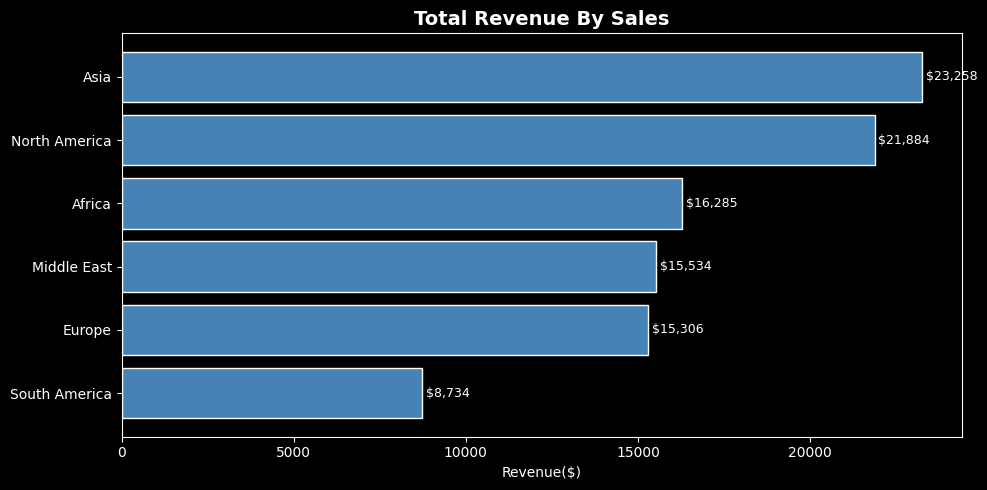

In [58]:
region_sales = df.groupby('region')['final_revenue'].sum().sort_values()

plt.figure(figsize=(10, 5))
bars = plt.barh(region_sales.index, region_sales.values, color='steelblue', edgecolor='white')
plt.title("Total Revenue By Sales", fontsize=14, fontweight='bold')
plt.xlabel("Revenue($)")
for bar, val in zip(bars, region_sales.values):
    plt.text(val + 100, bar.get_y() + bar.get_height() / 2,
             f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

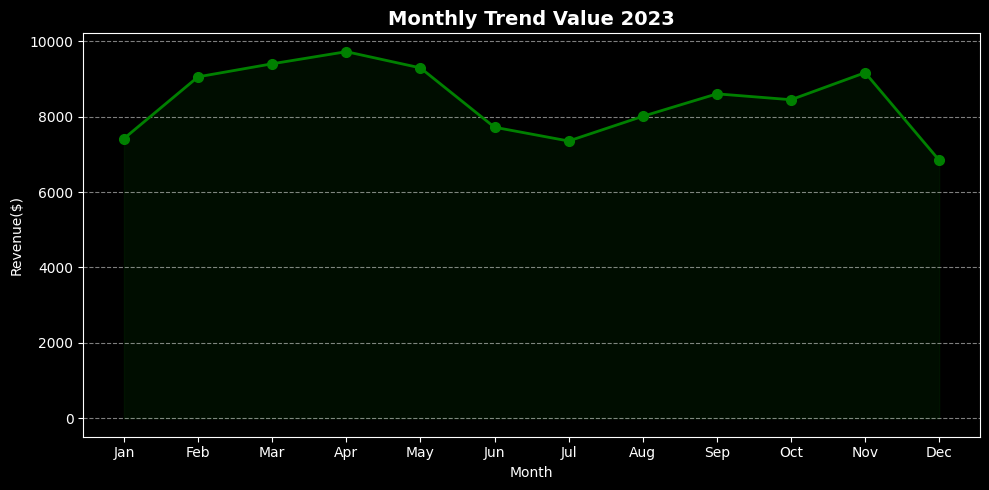

In [59]:
#Monthly Trend
monthly = df.groupby('month')['final_revenue'].sum()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='green',
         linewidth=2, markersize=7)
plt.fill_between(monthly.index, monthly.values, alpha=0.1, color='green')
plt.xticks(monthly.index, month_labels)
plt.title('Monthly Trend Value 2023', fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

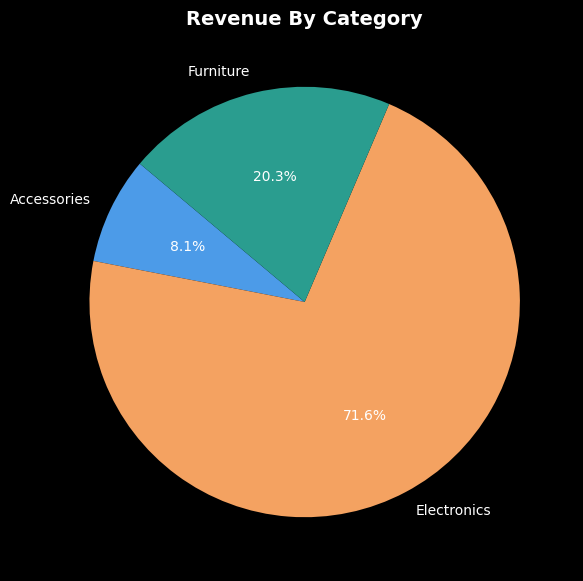

In [60]:
category = df.groupby('category')['final_revenue'].sum()

plt.figure(figsize=(6, 6))
plt.pie(category.values, labels=category.index,
        autopct='%1.1f%%', startangle=140,
        colors=['#4C9BE8', '#F4A261', '#2A9D8F'])
plt.title('Revenue By Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

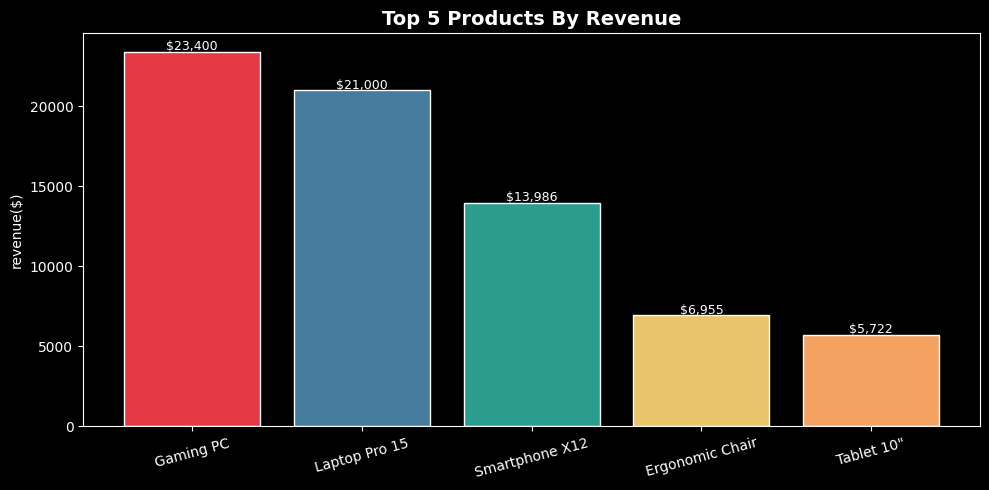

In [61]:
top_products = df.groupby('product')['final_revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
bars = plt.bar(top_products.index, top_products.values,
               color=['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261'],
               edgecolor='white')
plt.title('Top 5 Products By Revenue', fontsize=14, fontweight='bold')
plt.ylabel('revenue($)')
plt.xticks(rotation=15)
for bar, val in zip(bars, top_products.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 100,
             f'${val:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

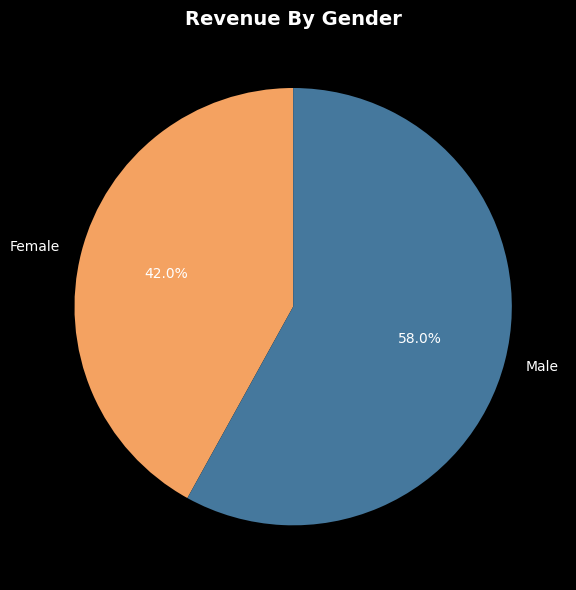

In [62]:
gender = df.groupby('gender')['final_revenue'].sum()

plt.figure(figsize=(6, 6))
plt.pie(gender.values, labels=gender.index,
        autopct='%1.1f%%', startangle=90,
        colors=['#F4A261', '#45789D'])
plt.title('Revenue By Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

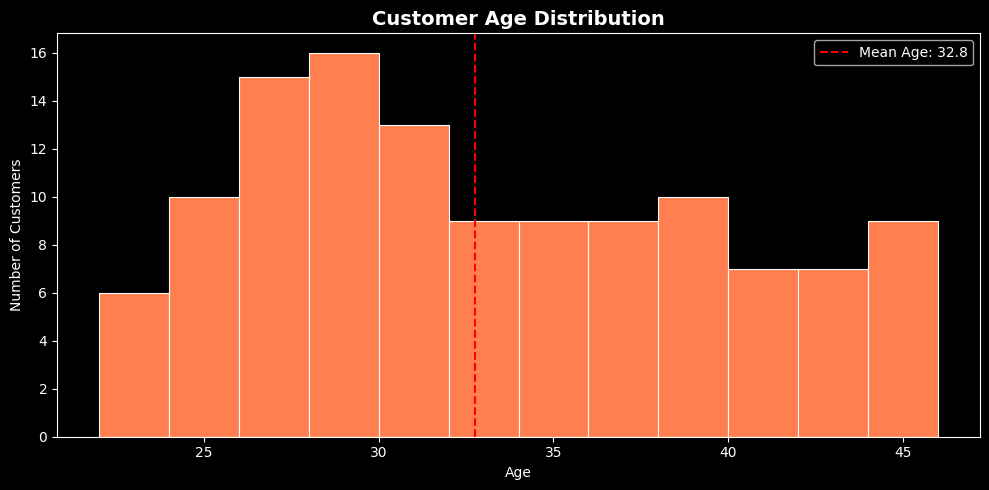

In [63]:
plt.figure(figsize=(10, 5))
plt.hist(df['age'], bins=12, color='coral',
         edgecolor='white', linewidth=0.8)
plt.title("Customer Age Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.axvline(df['age'].mean(), color='red', linestyle='--',
            label=f'Mean Age: {df["age"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
df.to_csv("global_sales_cleaned.csv", index=False)
print("✅ Exported: global_sales_cleaned.csv")
print(f"   Rows    : {len(df)}")
print(f"   Columns : {len(df.columns)}")
print(f"\nNew columns added:")
print("   → month, month_name, quarter, final_revenue")
print("\n🎯 Ready to load into Power BI!")

✅ Exported: global_sales_cleaned.csv
   Rows    : 120
   Columns : 18

New columns added:
   → month, month_name, quarter, final_revenue

🎯 Ready to load into Power BI!
